# Go/Stop - Object Detection

# 목차
1. 개발환경
2. 데이터셋
3. RetinaNet<br>
3-1. Train<br>
3-2. Inference<br>
3-3. Go/Stop Object Detection
4. Go/Stop Object Detection<br>
4-1. Test
5. 회고


## 1. 개발환경

In [ ]:
import os

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

# Helper libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import tensorflow_datasets as tfds

import copy
import cv2
from PIL import Image, ImageDraw

# 2. 데이터셋

In [ ]:
import urllib3
urllib3.disable_warnings()
(ds_train, ds_test), ds_info = tfds.load(
    'kitti',
    split=['train', 'test'],
    shuffle_files=True,
    with_info=True,
)

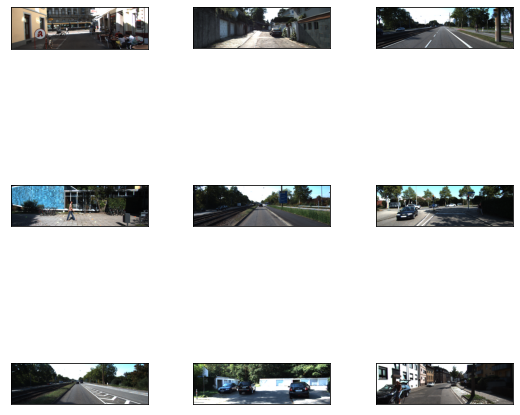

In [ ]:
fig = tfds.show_examples(ds_train, ds_info)

In [ ]:
ds_info

tfds.core.DatasetInfo(
    name='kitti',
    version=3.2.0,
    description='Kitti contains a suite of vision tasks built using an autonomous driving
platform. The full benchmark contains many tasks such as stereo, optical flow,
visual odometry, etc. This dataset contains the object detection dataset,
including the monocular images and bounding boxes. The dataset contains 7481
training images annotated with 3D bounding boxes. A full description of the
annotations can be found in the readme of the object development kit readme on
the Kitti homepage.',
    homepage='http://www.cvlibs.net/datasets/kitti/',
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=tf.uint8),
        'image/file_name': Text(shape=(), dtype=tf.string),
        'objects': Sequence({
            'alpha': tf.float32,
            'bbox': BBoxFeature(shape=(4,), dtype=tf.float32),
            'dimensions': Tensor(shape=(3,), dtype=tf.float32),
            'location': Tensor(shape=(3,), dtype

In [ ]:
TakeDataset = ds_train.take(1)

for example in TakeDataset:  
    print('------Example------')
    print(list(example.keys())) # example is `{'image': tf.Tensor, 'label': tf.Tensor}`
    image = example["image"]
    filename = example["image/file_name"].numpy().decode('utf-8')
    objects = example["objects"]

print('------objects------')
print(objects)

------Example------
['image', 'image/file_name', 'objects']
------objects------
{'alpha': <tf.Tensor: shape=(14,), dtype=float32, numpy=
array([-1.97, -1.99, -1.7 , -1.81, -2.11,  2.75,  1.76,  1.93,  1.9 ,
        1.88, -2.99,  1.56,  1.74,  1.67], dtype=float32)>, 'bbox': <tf.Tensor: shape=(14, 4), dtype=float32, numpy=
array([[0.13010696, 0.5862278 , 0.576123  , 0.6344265 ],
       [0.15705882, 0.6571244 , 0.601738  , 0.7072052 ],
       [0.2428075 , 0.19313408, 0.55815506, 0.23378837],
       [0.35665774, 0.5088692 , 0.56002676, 0.5274475 ],
       [0.28037432, 0.6259451 , 0.5853476 , 0.66390955],
       [0.11497326, 0.8804039 , 0.6296524 , 0.97975767],
       [0.2205615 , 0.8873102 , 0.62144387, 0.936042  ],
       [0.27502674, 0.29155898, 0.55122995, 0.32440227],
       [0.24994652, 0.26145396, 0.43826205, 0.3110824 ],
       [0.27093583, 0.26950726, 0.5568984 , 0.2948223 ],
       [0.24264705, 0.86004037, 0.63363636, 0.95084816],
       [0.45516044, 0.42310178, 0.5698396 , 0.457

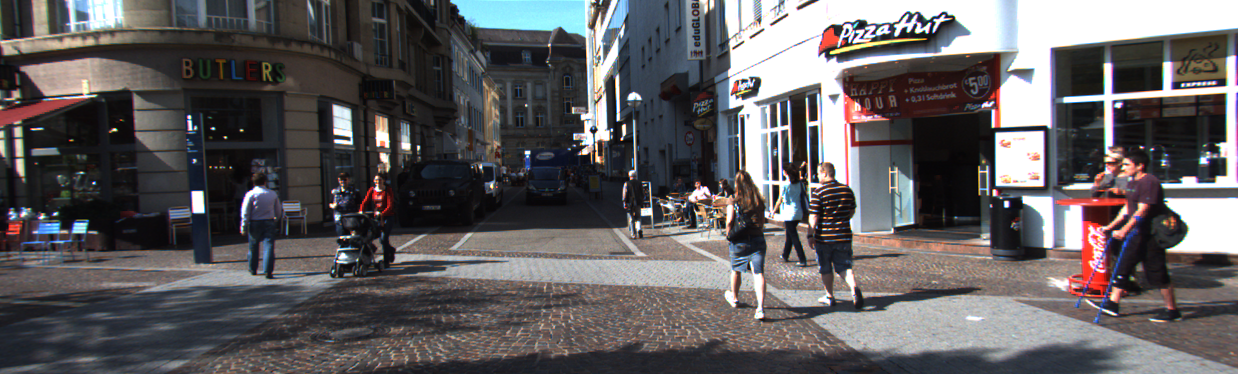

In [ ]:
img = Image.fromarray(image.numpy())
img

In [ ]:
def visualize_bbox(input_image, object_bbox):
    input_image = copy.deepcopy(input_image)
    draw = ImageDraw.Draw(input_image)

    # 바운딩 박스 좌표(x_min, x_max, y_min, y_max) 구하기
    width, height = input_image.size
    print('width:', width, ' height:', height)
    print(object_bbox.shape)
    x_min = object_bbox[:,1] * width
    x_max = object_bbox[:,3] * width
    y_min = height - object_bbox[:,0] * height
    y_max = height - object_bbox[:,2] * height

    # 바운딩 박스 그리기
    rects = np.stack([x_min, y_min, x_max, y_max], axis=1)
    for _rect in rects:
        print(_rect)
        draw.rectangle(_rect, outline=(255,0,0), width=2)
    print(input_image)
    return input_image

width: 1238  height: 374
(14, 4)
[725.75 325.34 785.42 158.53]
[813.52 315.26 875.52 148.95]
[239.09999 283.19    289.43    165.25   ]
[629.98004 240.61    652.98004 164.54999]
[774.92004 269.14    821.92004 155.08   ]
[1089.94     331.      1212.94     138.51001]
[1098.49     291.51    1158.8201   141.57999]
[360.95    271.14    401.61002 167.84   ]
[323.68    280.52002 385.12    210.09   ]
[333.65    272.66998 364.99002 165.71999]
[1064.73  283.25 1177.15  137.02]
[523.8     203.76999 566.3     160.87999]
[392.63 227.49 485.63 151.46]
[445.76 214.26 504.38 157.09]
<PIL.Image.Image image mode=RGB size=1238x374 at 0x7F4CA0408BD0>


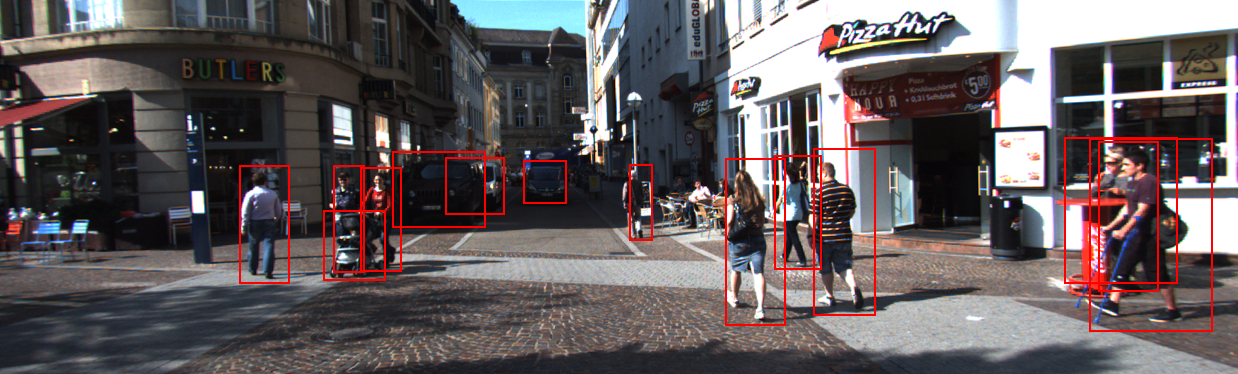

In [ ]:
visualize_bbox(img, objects['bbox'].numpy())

In [ ]:
data_dir = '/data'
img_dir = os.getenv('HOME')+ '/kitti_images'
train_csv_path = data_dir + '/kitti_train.csv'

In [ ]:
# parse_dataset 함수를 구현해 주세요.
def parse_dataset(dataset, img_dir="kitti_images", total=0):
    if not os.path.exists(img_dir):
        os.mkdir(img_dir)
    # Dataset의 claas를 확인하여 class에 따른 index를 확인해둡니다.
    # 저는 기존의 class를 차와 사람으로 나누었습니다.
    type_class_map = {
        0: "car",
        1: "car",
        2: "car",
        3: "person",
        4: "person",
        5: "person",
    }
    # Keras retinanet을 학습하기 위한 dataset을 csv로 parsing하기 위해서 필요한 column을 가진 pandas.DataFrame을 생성합니다.
    df = pd.DataFrame(columns=["img_path", "x1", "y1", "x2", "y2", "class_name"])
    for item in tqdm(dataset, total=total):
        filename = item['image/file_name'].numpy().decode('utf-8')
        img_path = os.path.join(img_dir, filename)

        img = Image.fromarray(item['image'].numpy())
        img.save(img_path)
        object_bbox = item['objects']['bbox']
        object_type = item['objects']['type'].numpy()
        width, height = img.size

        # tf.dataset의 bbox좌표가 0과 1사이로 normalize된 좌표이므로 이를 pixel좌표로 변환합니다.
        x_min = object_bbox[:,1] * width
        x_max = object_bbox[:,3] * width
        y_min = height - object_bbox[:,2] * height
        y_max = height - object_bbox[:,0] * height

        # 한 이미지에 있는 여러 Object들을 한 줄씩 pandas.DataFrame에 append합니다.
        rects = np.stack([x_min, y_min, x_max, y_max], axis=1).astype(np.int)
        for i, _rect in enumerate(rects):
            _type = object_type[i]
            if _type not in type_class_map.keys():
                continue
            df = df.append({
                "img_path": img_path,
                "x1": _rect[0],
                "y1": _rect[1],
                "x2": _rect[2],
                "y2": _rect[3],
                "class_name": type_class_map[_type]
            }, ignore_index=True)
            break
    return df

In [ ]:
df_train = parse_dataset(ds_train, img_dir, total=ds_info.splits['train'].num_examples)

  0%|          | 0/6347 [00:00<?, ?it/s]/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:34: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
100%|██████████| 6347/6347 [19:22<00:00,  5.46it/s]


In [ ]:
df_train.to_csv(train_csv_path, sep=',',index = False, header=False)

In [ ]:
test_csv_path = data_dir + '/kitti_test.csv'

In [ ]:
df_test = parse_dataset(ds_test, img_dir, total=ds_info.splits['test'].num_examples)

  0%|          | 0/711 [00:00<?, ?it/s]/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:34: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
100%|██████████| 711/711 [02:12<00:00,  5.36it/s]


In [ ]:
df_test.to_csv(test_csv_path, sep=',',index = False, header=False)

In [ ]:
class_txt_path = data_dir + '/classes.txt'

In [ ]:
def save_class_format(path="./classes.txt"):
    class_type_map = {
        "car" : 0,
        "person": 1
    }
    with open(path, mode='w', encoding='utf-8') as f:
        for k, v in class_type_map.items():
            f.write(f"{k},{v}\n")

In [ ]:
save_class_format(class_txt_path)

# 3. RetinaNet

## 3-1. Train

In [ ]:
# RetinaNet 훈련이 시작됩니다!! 50epoch 훈련에 1시간 이상 소요될 수 있습니다. 
!cd ~/object_detection && python keras-retinanet/keras_retinanet/bin/train.py --gpu 0 --multiprocessing --workers 4 --batch-size 2 --epochs 50 --steps 195 csv /data/kitti_train.csv /data/classes.txt

1 Physical GPUs, 1 Logical GPUs
Creating model, this may take a second...
/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/adam.py:105: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)
Model: "retinanet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 conv1 (Conv2D)                 (None, None, None,   9408        ['input_1[0][0]']                
                                64)                                                               
                       

## 3-2. Inference

In [ ]:
!cd ~/object_detection && python keras-retinanet/keras_retinanet/bin/convert_model.py ./snapshots/resnet50_csv_50.h5 ./snapshots/resnet50_csv_50_infer.h5

In [ ]:
%matplotlib inline

# automatically reload modules when they have changed
%load_ext autoreload
%autoreload 2

# import keras
import keras

# import keras_retinanet
from keras_retinanet import models
from keras_retinanet.models import load_model
from keras_retinanet.utils.image import read_image_bgr, preprocess_image, resize_image
from keras_retinanet.utils.visualization import draw_box, draw_caption
from keras_retinanet.utils.colors import label_color
from keras_retinanet.utils.gpu import setup_gpu

# import miscellaneous modules
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
import time

gpu = '0'
setup_gpu(gpu)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Physical devices cannot be modified after being initialized
1 Physical GPUs, 1 Logical GPUs


In [ ]:
dir_path = '/'
model_path = os.path.join(dir_path, 'snapshots', 'resnet50_csv_50_infer.h5')
model = load_model(model_path, backbone_name='resnet50')

In [ ]:
img_path = '/test/go_1.png'

In [ ]:
# inference_on_image 함수를 구현해 주세요.
def inference_on_image(model, img_path="/test/go_1.png", visualize=True):
    image = read_image_bgr(img_path)

    # copy to draw on
    draw = image.copy()
    draw = cv2.cvtColor(draw, cv2.COLOR_BGR2RGB)

    color_map = {
        0: (0, 0, 255), # blue
        1: (255, 0, 0) # red
    }

    # preprocess image for network
    image = preprocess_image(image)
    image, scale = resize_image(image)

    # process image
    boxes, scores, labels = model.predict_on_batch(np.expand_dims(image, axis=0))

    # correct for image scale
    boxes /= scale

    # display images
    if  visualize:
        for box, score, label in zip(boxes[0], scores[0], labels[0]):
            print(box)
            if score < 0.5:
                break
            b = box.astype(int)
            draw_box(draw, b, color=color_map[label])

            caption = "{:.3f}".format(score)
            draw_caption(draw, b, caption)

        plt.figure(figsize=(15, 15))
        plt.axis('off')
        plt.imshow(draw)
        plt.show()            

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: Unknown node type <gast.gast.Expr object at 0x7f4caa222550>
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: Unknown node type <gast.gast.Expr object at 0x7f4caa222550>
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: Unknown node type <gast.gast.Expr object at 0x7f4caa222550>
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
[594.7124  175.4857  626.9961  206.13683]
[191.61409 136.62624 358.7486  229.35909]


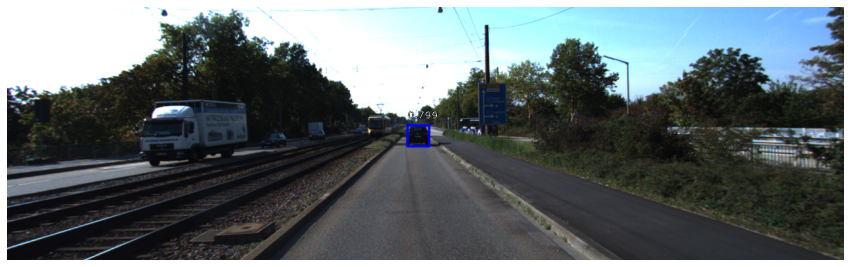

In [ ]:
inference_on_image(model, img_path=img_path)

[775.10114 147.93983 844.57574 313.45715]
[772.29034 148.97285 842.99805 306.3881 ]


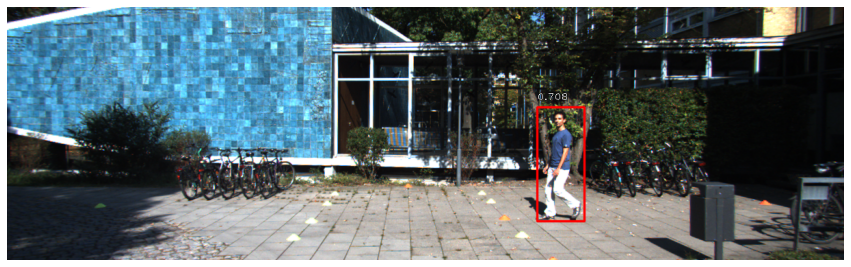

In [ ]:
img_path = '/test/stop_1.png'
inference_on_image(model, img_path=img_path)

## 3-3. Go/Stop Object Detection


In [ ]:
def self_drive_assist(img_path, size_limit=300):
    image = read_image_bgr(img_path)
        
    color_map = {
        0: (0, 0, 255), # blue
        1: (255, 0, 0) # red
    }
    
    # preprocess image for network
    image = preprocess_image(image)
    image, scale = resize_image(image)
    
    # process image
    boxes, scores, labels = model.predict_on_batch(np.expand_dims(image, axis=0))
    
    # correct for image scale
    boxes /= scale
    
    # 코드 구현
    # 정지조건에 맞으면 return "Stop"
    # 아닌 경우 return "Go"
    for box, score, label in zip(boxes[0], scores[0], labels[0]):
        if score < 0.5:
            break
        if label == 1:
            return "Stop"
        if box[2] - box[0] >= size_limit or box[3] - box[1] >= size_limit:
            return "Stop"
    return "Go"    

In [ ]:
def test_system(func):
    work_dir = os.getenv('HOME')+'/object_detection'
    score = 0
    test_set=[
        ("test/stop_1.png", "Stop"),
        ("test/stop_2.png", "Stop"),
        ("test/stop_3.png", "Stop"),
        ("test/stop_4.png", "Stop"),
        ("test/stop_5.png", "Stop"),
        ("test/go_1.png", "Go"),
        ("test/go_2.png", "Go"),
        ("test/go_3.png", "Go"),
        ("test/go_4.png", "Go"),
        ("test/go_5.png", "Go"),
    ]

    for image_file, answer in test_set:
        image_path = work_dir + '/' + image_file
        pred = func(image_path)
        if pred == answer:
            score += 10
    print(f"{score}점입니다.")

In [ ]:
test_system(self_drive_assist)

100점입니다.


# 회고

KITTI 데이터셋과 RetinaNet을 이용하여 GO/STOP Object detection system을 만들었다.
